In [3]:
!pip install rioxarray rasterio xarray pystac-client planetary-computer geopandas odc.stac stackstac
!pip install --upgrade rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 18.4 MB/s eta 0:00:00


In [4]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
#import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets
import xarray as xr

# Geospatial raster data handling
import rioxarray as rxr

# Geospatial data analysis
#import geopandas as gpd

# Geospatial operations
import rasterio
from rasterio import windows
from rasterio import features
from rasterio import warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

# Image Processing
from PIL import Image

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import tf_keras as keras  # Use tf_keras instead of tf.keras
from tf_keras import layers
from tf_keras.models import Model, Sequential
from tf_keras.layers import Input, Dropout, Dense
from tf_keras.optimizers import Adam
import tensorflow_probability as tfp
import tensorflow_probability.python.layers as tfpl
tfd = tfp.distributions
from tf_keras.callbacks import CSVLogger

# Planetary Computer Tools
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# Others
import os
from tqdm import tqdm



In [5]:
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined
    dataset2 - Dataset 2 to be combined
    '''

    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [6]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.

def map_satellite_data(tiff_path, csv_path):

    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)

    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    vals = [[] for _ in range(n_inputs)]


# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)

        for i in range(n_inputs):
            tmp = data.sel(x=lon, y=lat, band=i, method='nearest').values
            vals[i].append(tmp)

    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df = pd.DataFrame()
    for i in range(n_inputs):
        df[names[i]] = vals[i]

    return df


In [7]:
# Constants
n_inputs = 28
names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12", "ndwi", "ndvi", "ndbi",
        "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)", "B12 (pooled)", "ndwi (pooled)", "ndvi (pooled)", "ndbi (pooled)",
        "building_count_0-25ft", "building_impact_0-25ft", "building_count_25-50ft", "building_impact_25-50ft", "building_count_50-100ft", "building_impact_50-100ft", "building_count_100-200ft", "building_impact_100-200ft", "building_count_200-500ft", "building_impact_200-500ft",
        "tree_count_0-25ft", "tree_impact_0-25ft", "tree_count_25-50ft", "tree_impact_25-50ft", "tree_count_50-100ft", "tree_impact_50-100ft", "tree_count_100-200ft", "tree_impact_100-200ft", "tree_count_200-500ft", "tree_impact_200-500ft"]
UhiData_FileName = "Data/Training_data_uhi_index.csv"
satellite_data =  "Data/S2_median_fullBands_indeces.tiff"
tree_building_uhi_data = "Data/LATEST_combined_tree_building_uhi_features.csv"
test_size = 0.3

# Open the GeoTIFF file
tiff_path = "Data/S2_median_fullBands_indeces.tiff"

In [8]:
# Would be faster in a df
feature_data = map_satellite_data(satellite_data, UhiData_FileName)

Mapping values: 100%|██████████| 11229/11229 [07:08<00:00, 26.22it/s]


In [9]:
print(feature_data)

         B01    B02     B03     B04     B05     B06     B07     B08     B8A  \
0      841.5  841.5  1053.0  1155.0  1206.0  1481.5  1660.5  1721.0  1832.0   
1      841.5  841.5  1053.0  1155.0  1206.0  1481.5  1660.5  1721.0  1832.0   
2      841.5  841.5   646.0   823.0   777.0  1130.5  1883.0  2117.5  2241.0   
3      841.5  841.5   625.0   766.0   741.5  1130.5  1883.0  2117.5  2200.0   
4      841.5  841.5   659.5   763.0   708.5  1077.5  1783.0  2042.0  2161.0   
...      ...    ...     ...     ...     ...     ...     ...     ...     ...   
11224  462.5  462.5   491.0   725.5   501.0   999.0  2612.0  3111.5  3152.0   
11225  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11226  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11227  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11228  462.5  462.5   640.0   835.0   723.0  1014.5  2755.0  3407.5  3341.0   

          B11  ...           B05 (pooled)          

In [10]:
import re
# Identify object columns
object_cols = feature_data.select_dtypes(include=['object']).columns

# Convert to numeric
for col in object_cols:
    feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')

object_cols = feature_data.select_dtypes(include=['object']).columns

# Clean up inconsistencies (example for one column)
for col in ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12',
            "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)"]:
    feature_data[col] = feature_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Convert to numeric
for col in ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12',
            "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)"]:
    feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')
    print(feature_data[col].dtype)
# Redo columns
epsilon = 1e-10  # A small constant to avoid division by zero
feature_data["ndwi"] = (feature_data["B03"] - feature_data["B08"]) / (feature_data["B03"] + feature_data["B08"] + epsilon)
feature_data["ndbi"] = (feature_data["B11"] - feature_data["B08"]) / (feature_data["B11"] + feature_data["B08"] + epsilon)
feature_data["ndvi"] = (feature_data["B08"] - feature_data["B04"]) / (feature_data["B08"] + feature_data["B04"] + epsilon)
feature_data["ndwi (pooled)"] = (feature_data["B03 (pooled)"] - feature_data["B08 (pooled)"]) / (feature_data["B03 (pooled)"] + feature_data["B08 (pooled)"] + epsilon)
feature_data["ndbi (pooled)"] = (feature_data["B11 (pooled)"] - feature_data["B08 (pooled)"]) / (feature_data["B11 (pooled)"] + feature_data["B08 (pooled)"] + epsilon)
feature_data["ndvi (pooled)"] = (feature_data["B08 (pooled)"] - feature_data["B04 (pooled)"]) / (feature_data["B08 (pooled)"] + feature_data["B04 (pooled)"] + epsilon)


float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64


In [11]:
# Combining ground data and feature data into a single dataset.
ground_df = pd.read_csv(UhiData_FileName)
tree_building_df = pd.read_csv(tree_building_uhi_data)
uhi_data = combine_two_datasets(ground_df,feature_data)
uhi_data = combine_two_datasets(uhi_data, tree_building_df)

In [12]:
# Old CSV files/dataset
# Remove duplicate rows from the DataFrame based on specified columns and keep the first occurrence
columns_to_check = ['B01','B04','B06','B08','ndvi']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    uhi_data[col] = uhi_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Now remove duplicates
uhi_data = uhi_data.drop_duplicates(subset=columns_to_check, keep='first')
uhi_data['B01 (pooled)']

,B01 (pooled)
0,-0.011038
2,-0.182898
3,-0.173959
4,-0.143840
6,-0.208950
...,...
11219,-0.192943
11220,-0.256072
11223,-0.241678
11225,-0.299618


In [13]:
# This is the new data - I haven't done anything with it yet
# Load the CSV file
df = pd.read_csv('Data/complete_uhi_satellite_data_20250504_225131.csv')

# Drop longitude and latitude columns
df = df.drop(columns=['longitude', 'latitude'], errors='ignore')

# Check for columns with nan
print(df.isna().sum()[df.isna().sum() > 0])

df = df.fillna(df.median(numeric_only=True))
print(df.columns)


Latitude           6229
Longitude          6229
B02_ring1_mean     6229
B02_ring1_std      6229
B03_ring1_mean     6229
B03_ring1_std      6229
B04_ring1_mean     6229
B04_ring1_std      6229
B08_ring1_mean     6229
B08_ring1_std      6229
B11_ring1_mean     6229
B11_ring1_std      6229
B12_ring1_mean     6229
B12_ring1_std      6229
ndvi_ring1_mean    6229
ndvi_ring1_std     6229
ndbi_ring1_mean    6229
ndbi_ring1_std     6229
ndwi_ring1_mean    6229
ndwi_ring1_std     6229
dtype: int64
Index(['Longitude_features', 'Latitude_features', 'datetime_features',
       'UHI Index_features', 'original_index', 'B01', 'B02', 'B03', 'B04',
       'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndwi', 'ndvi', 'ndbi',
       'B01 (pooled)', 'B02 (pooled)', 'B03 (pooled)', 'B04 (pooled)',
       'B05 (pooled)', 'B06 (pooled)', 'B07 (pooled)', 'B08 (pooled)',
       'B8A (pooled)', 'B11 (pooled)', 'B12 (pooled)', 'ndwi (pooled)',
       'ndvi (pooled)', 'ndbi (pooled)', 'uhi_id', 'Longitude_tree'

In [14]:
# Load data, normalize distributions
model_data = uhi_data[names + ['UHI Index']]
model_data = model_data.loc[:, ~model_data.columns.duplicated()]
# Calculate mean and standard deviation for each column
data_mean = model_data.mean()
data_std = model_data.std()
print(model_data.dtypes)
# Replace zero standard deviations with 1 to avoid division by zero
data_std = data_std.replace(0, 1)

# Normalize the data using vectorized operations
md_data_std = (model_data - data_mean) / data_std

B01                          float64
B02                          float64
B03                          float64
B04                          float64
B05                          float64
B06                          float64
B07                          float64
B08                          float64
B8A                          float64
B11                          float64
B12                          float64
ndwi                         float64
ndvi                         float64
ndbi                         float64
B01 (pooled)                 float64
B02 (pooled)                 float64
B03 (pooled)                 float64
B04 (pooled)                 float64
B05 (pooled)                 float64
B06 (pooled)                 float64
B07 (pooled)                 float64
B08 (pooled)                 float64
B8A (pooled)                 float64
B11 (pooled)                 float64
B12 (pooled)                  object
ndwi (pooled)                float64
ndvi (pooled)                float64
n

In [47]:

# Divide data into training and testing
X = md_data_std.drop(columns=['UHI Index']).values
print(X.astype(np.float64).dtype)
y = md_data_std['UHI Index'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=123)

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
y_train = y_train.astype(np.float64)
y_test = y_test.astype(np.float64)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

float64
(5848, 48)
(5848,)
(2507, 48)
(2507,)


In [16]:
def test_model(model, X_test, y_test):
    y_pred = model.predict(X_test).flatten()  # Flatten if necessary based on model output
    print(f"MSE: {mean_squared_error(y_test, y_pred)}")  # Use y_test directly
    print(f"r2: {r2_score(y_test, y_pred)}")  # Use y_test directly
    y_lazy_pred = np.full(len(y_test), np.mean(y_test))  # More efficient lazy prediction
    print(f"Lazy MSE: {mean_squared_error(y_test, y_lazy_pred)}")  # Use y_test directly
    print(f"Lazy r2: {r2_score(y_test, y_lazy_pred)}")  # Use y_test directly

In [17]:
# Standard Model
import os # Import the os module to create directories

# Create the 'Model_Stats' directory if it doesn't exist
if not os.path.exists("Model_Stats"):
    os.makedirs("Model_Stats")

model1 = Sequential([
    Dense(64, activation = 'relu', input_shape=(48,) ),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(1, activation = 'linear'),
])
model1.compile(optimizer=Adam(learning_rate=0.001) , loss = "MSE" )
log = CSVLogger(f"Model_Stats/standard_training.log", append=True)
model1.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[log])

Epoch 1/100
165/165 [==============================] - 1s 3ms/step - loss: 0.8711 - val_loss: 0.7831
Epoch 2/100
165/165 [==============================] - 0s 2ms/step - loss: 0.7490 - val_loss: 0.7322
Epoch 3/100
165/165 [==============================] - 0s 2ms/step - loss: 0.7079 - val_loss: 0.7083
Epoch 4/100
165/165 [==============================] - 0s 2ms/step - loss: 0.6733 - val_loss: 0.6997
Epoch 5/100
165/165 [==============================] - 0s 2ms/step - loss: 0.6497 - val_loss: 0.6582
Epoch 6/100
165/165 [==============================] - 0s 2ms/step - loss: 0.6321 - val_loss: 0.6387
Epoch 7/100
165/165 [==============================] - 0s 2ms/step - loss: 0.6024 - val_loss: 0.6190
Epoch 8/100
165/165 [==============================] - 0s 2ms/step - loss: 0.5860 - val_loss: 0.6058
Epoch 9/100
165/165 [==============================] - 0s 2ms/step - loss: 0.5717 - val_loss: 0.6137
Epoch 10/100
165/165 [==============================] - 0s 2ms/step - loss: 0.5697 - val_lo

79/79 [==============================] - 0s 1ms/step
MSE: 0.44777918987877563
r2: 0.5529839081719059
Lazy MSE: 1.0017070930211052
Lazy r2: 0.0


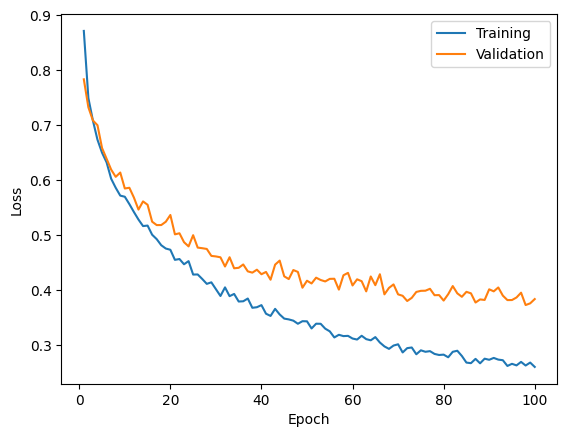

In [18]:
test_model(model1, X_test=X_test, y_test=y_test)
log = pd.read_csv(f"Model_Stats/standard_training.log")
training_loss = log["loss"]
validation_loss = log["val_loss"]
plt.plot(np.arange(1, len(training_loss) + 1), training_loss, label="Training")
plt.plot(np.arange(1, len(validation_loss) + 1), validation_loss, label="Validation")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
# Fixed prior: standard normal, wrapped in Independent
def prior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.DistributionLambda(
            lambda t: tfd.Independent(
                tfd.Normal(loc=tf.zeros(n), scale=1.0),
                reinterpreted_batch_ndims=1)
        )
    ])

def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(
            tfpl.MultivariateNormalTriL.params_size(n),
            dtype=dtype,
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)  # small noise
        ),
        tfpl.MultivariateNormalTriL(n)
    ])


In [20]:
def gauss(y_true, y_pred, epsilon=1e-6):
    mean = y_pred[:, 0]  # predicted mean
    log_var = y_pred[:, 1]  # predicted log variance (aleatoric uncertainty)

    # Stabilize variance calculation: ensure that variance is never zero or too small
    variance = tf.exp(log_var) + epsilon  # Adding epsilon to avoid zero variance
    precision = 1.0 / variance

    # Negative Log-Likelihood: NLL = 0.5 * (log_var + (y_true - mean)^2 / variance)
    nll = 0.5 * (log_var + tf.square(y_true - mean) * precision)

    # Return the mean NLL
    return tf.reduce_mean(nll)

# Bayesian Model
inputs = Input(shape=(48,))
x = tfp.layers.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight = 1e-6,
    activation='relu')(inputs)
outputs = Dense(1, activation='linear')(x)



model2 = Model(inputs=inputs, outputs=outputs)
model2.compile(optimizer=Adam(1e-4), loss="mse")
log = CSVLogger(f"Model_Stats/bnn_training.log", append=True)
model2.fit(X_train, y_train, epochs=200, validation_split=0.1, callbacks=[log])

Epoch 1/200
165/165 [==============================] - 4s 17ms/step - loss: 106.4244 - val_loss: 114.9400
Epoch 2/200
165/165 [==============================] - 3s 19ms/step - loss: 81.4791 - val_loss: 89.1615
Epoch 3/200
165/165 [==============================] - 2s 14ms/step - loss: 72.4384 - val_loss: 76.6695
Epoch 4/200
165/165 [==============================] - 2s 13ms/step - loss: 69.0456 - val_loss: 65.3109
Epoch 5/200
165/165 [==============================] - 2s 13ms/step - loss: 58.4444 - val_loss: 64.4147
Epoch 6/200
165/165 [==============================] - 2s 14ms/step - loss: 48.8602 - val_loss: 51.4881
Epoch 7/200
165/165 [==============================] - 3s 21ms/step - loss: 47.0324 - val_loss: 50.4385
Epoch 8/200
165/165 [==============================] - 2s 14ms/step - loss: 43.2935 - val_loss: 39.4445
Epoch 9/200
165/165 [==============================] - 2s 13ms/step - loss: 38.2870 - val_loss: 48.6865
Epoch 10/200
165/165 [==============================] - 2s 14m

In [21]:
# Monte Carlo sampling at test time
preds = np.array([model2.predict(X_test, batch_size=64) for _ in range(50)])
mean_preds = preds.mean(axis=0)

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, mean_preds))
print("R2:", r2_score(y_test, mean_preds))



40/40 [==============================] - 0s 3ms/step
MSE: 0.8112678028634036
R2: 0.1901147466005707


In [42]:
# Tried plugging in BNN into Chat and changing posterior and prior but got an
# error with params
import tensorflow as tf
import numpy as np
import tensorflow_probability as tfp

# Ensure X_train and y_train are tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

# Check shapes of inputs
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

tfd = tfp.distributions
tfpl = tfp.layers

# Define prior function
def prior_fn(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return tfd.Independent(
        tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1.0),
        reinterpreted_batch_ndims=1
    )

# Define posterior function
def posterior_fn(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    c = np.log(np.expm1(1.0))  # Softplus inverse

    def posterior():
        loc = tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype), name='posterior_loc')
        raw_scale = tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype), name='posterior_scale')
        scale = 1e-5 + tf.nn.softplus(c + raw_scale)
        return tfd.Independent(
            tfd.Normal(loc=loc, scale=scale),
            reinterpreted_batch_ndims=1
        )

    return posterior

# Test prior and posterior functions (optional)
# You can test by printing the outputs
kernel_size = 48  # Your input features
bias_size = 0
dtype = tf.float32

prior = prior_fn(kernel_size, bias_size, dtype)
posterior = posterior_fn(kernel_size, bias_size, dtype)
print(prior)
print(posterior)

# Model inputs
inputs = tf.keras.Input(shape=(48,))  # Input shape of the features

# Apply DenseVariational layer to the inputs, this returns a tensor (not a layer)
output_params = tfpl.DenseVariational(
    units=2,  # 1 for mean, 1 for log variance
    make_posterior_fn=posterior_fn,  # Pass posterior function
    make_prior_fn=prior_fn,  # Pass prior function
    kl_weight=1 / X_train.shape[0],  # KL-divergence weight
)(inputs)  # Apply the layer to the inputs

# Now output_params is a tensor containing both mean and log variance
mean, log_var = output_params[:, 0], output_params[:, 1]  # Split the tensor into mean and log_var

# Define the final output distribution: Normal with the predicted mean and log variance
outputs = tfpl.DistributionLambda(
    lambda t: tfd.Normal(loc=mean, scale=tf.exp(0.5 * log_var))  # Standard deviation is exp(0.5 * log_var)
)(mean)  # You can use 'mean' as the input here, since it already holds the correct values.




X_train shape: (5848, 48)
y_train shape: (5848,)
tfp.distributions.Independent("IndependentNormal", batch_shape=[], event_shape=[48], dtype=float32)
<function posterior_fn.<locals>.posterior at 0x79037467a020>


AttributeError: 'tuple' object has no attribute 'rank'

In [52]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.optimizers import Adam

# Define the MCDropout model class
class MCDropoutNet(tf.keras.Model):
    def __init__(self):
        super(MCDropoutNet, self).__init__()
        self.fc1 = tf.keras.layers.Dense(50, activation='relu', input_shape=(48,))
        self.dropout = tf.keras.layers.Dropout(0.5)
        self.fc2 = tf.keras.layers.Dense(1)

    def call(self, inputs, training=False):
        x = self.fc1(inputs)
        x = self.dropout(x, training=training)  # Dropout is active during training and testing
        return self.fc2(x)

# Function for Monte Carlo Dropout Prediction with Uncertainty
def predict_with_uncertainty(f_model, X, n_iter=100):
    f_model.trainable = False  # Disable training (not needed)

    # Predict with dropout active during inference
    predictions = []
    for _ in range(n_iter):
        preds = f_model(X, training=True)  # Set `training=True` to keep dropout active
        predictions.append(preds.numpy())

    predictions = np.array(predictions)
    prediction_mean = predictions.mean(axis=0)
    prediction_std = predictions.std(axis=0)
    return prediction_mean, prediction_std


model = MCDropoutNet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
log = CSVLogger('Model_Stats/mc_dropout.log', append=True)

# Train the model and manually log predictions and uncertainties
for epoch in range(200):
    history = model.fit(X_train, y_train, epochs=1, validation_split=0.1, batch_size=32, verbose=0, callbacks=[log])

    # Extract the training and validation loss from the history
    train_loss = history.history['loss'][0]
    val_loss = history.history['val_loss'][0]
    print(f"Epoch {epoch + 1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

    # Predict with uncertainty after each epoch
    prediction_mean, prediction_std = predict_with_uncertainty(model, X_train, n_iter=100)

    # Convert the predictions and uncertainty to a DataFrame
    log_data = pd.DataFrame({
        'epoch': [epoch + 1] * len(prediction_mean),
        'prediction_mean': prediction_mean.flatten(),
        'prediction_std': prediction_std.flatten()
    })

    # Save to CSV (append mode)
    log_data.to_csv('Model_Stats/mc_dropout_predictions.csv', mode='a', header=not pd.io.common.file_exists('Model_Stats/mc_dropout_predictions.csv'), index=False)

print("Training complete.")


Epoch 1: Training Loss = 2.1898, Validation Loss = 1.2469
Epoch 2: Training Loss = 1.9168, Validation Loss = 1.1381
Epoch 3: Training Loss = 1.7316, Validation Loss = 1.0675
Epoch 4: Training Loss = 1.5827, Validation Loss = 1.0177
Epoch 5: Training Loss = 1.4435, Validation Loss = 0.9813
Epoch 6: Training Loss = 1.3440, Validation Loss = 0.9480
Epoch 7: Training Loss = 1.3073, Validation Loss = 0.9273
Epoch 8: Training Loss = 1.2388, Validation Loss = 0.9044
Epoch 9: Training Loss = 1.1776, Validation Loss = 0.8842
Epoch 10: Training Loss = 1.1657, Validation Loss = 0.8703
Epoch 11: Training Loss = 1.1600, Validation Loss = 0.8554
Epoch 12: Training Loss = 1.0896, Validation Loss = 0.8470
Epoch 13: Training Loss = 1.0443, Validation Loss = 0.8374
Epoch 14: Training Loss = 1.0700, Validation Loss = 0.8278
Epoch 15: Training Loss = 1.0303, Validation Loss = 0.8193
Epoch 16: Training Loss = 0.9517, Validation Loss = 0.8117
Epoch 17: Training Loss = 0.9525, Validation Loss = 0.8062
Epoch 

In [57]:
predictions_df = pd.read_csv('Model_Stats/mc_dropout_predictions.csv')

# View the first few rows of the dataframe to understand the structure
print(predictions_df.head())

prediction_mean = predictions_df['prediction_mean'].values
print(len(y_train))
print(prediction_mean.shape[0])
# Ensure that y_train and prediction_mean have the same length
assert len(y_train) == len(prediction_mean), "The true labels and predictions should have the same length"

   epoch  prediction_mean  prediction_std
0      1        -0.547501        0.578152
1      1         0.216230        0.536277
2      1         0.279774        0.611378
3      1        -1.837459        3.013396
4      1        -0.677397        0.490441
5848
1169600


AssertionError: The true labels and predictions should have the same length